In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import pickle

In [3]:
df = pd.read_csv(r"E:\coding\ML\house_prediction\Housing_price_data.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

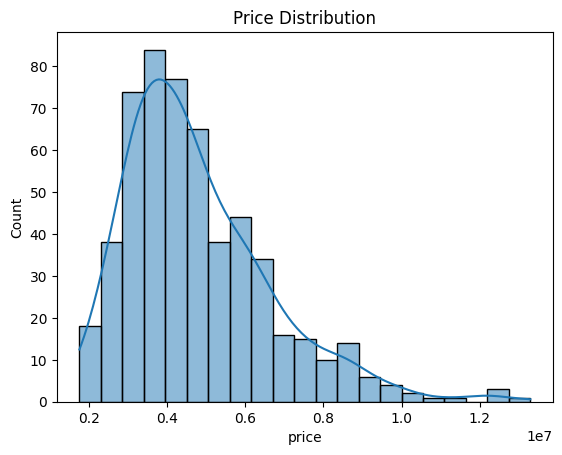

In [8]:
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

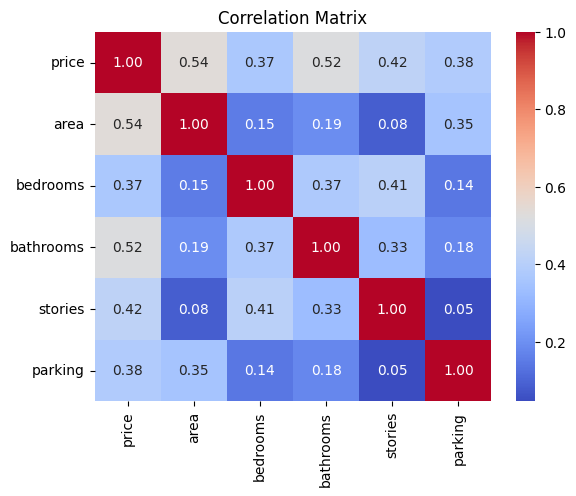

In [9]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [10]:
df['price'] = np.log1p(df['price'])

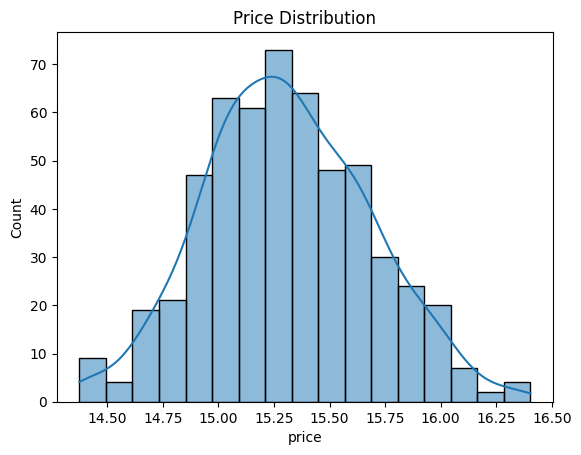

In [11]:
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [13]:
scaler = StandardScaler()
df["area"] = scaler.fit_transform(df[["area"]])

In [14]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [15]:
df=df.rename(columns={'hotwaterheating':'hot_water_heating', 'airconditioning':'air_conditioning', 'prefarea': 'prefered_area', 'furnishingstatus':'furnished'})

In [16]:
le = LabelEncoder()
df["mainroad"] = le.fit_transform(df["mainroad"])
df["guestroom"] = le.fit_transform(df["guestroom"])
df["basement"] = le.fit_transform(df["basement"])
df["hot_water_heating"] = le.fit_transform(df["hot_water_heating"])
df["air_conditioning"] = le.fit_transform(df["air_conditioning"])
df["prefered_area"] = le.fit_transform(df["prefered_area"])
df["furnished"] = le.fit_transform(df["furnished"])

In [17]:
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hot_water_heating,air_conditioning,parking,prefered_area,furnished
0,16.403275,1.046726,4,2,3,1,0,0,0,1,2,1,0
1,16.321037,1.757010,4,4,4,1,0,0,0,1,3,0,0
2,16.321037,2.218232,3,2,2,1,0,1,0,0,2,1,1


In [18]:
X = df.drop(columns=['price'])
Y = df['price']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [20]:
lr = LinearRegression()
xgbr = XGBRegressor(n_estimators=50,max_depth=3,learning_rate=0.05,random_state=42)  

In [21]:
lr.fit(x_train,y_train)
xgbr.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [22]:
lr_log_pred=lr.predict(x_test)
xgbr_log_pred=xgbr.predict(x_test)

In [23]:
y_test_real = np.expm1(y_test)
lr_pred = np.expm1(lr_log_pred)
xgbr_pred = np.expm1(xgbr_log_pred)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [25]:
lr_mae = mean_absolute_error(y_test_real, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test_real, lr_pred))
lr_r2 = r2_score(y_test_real, lr_pred)

xgb_mae = mean_absolute_error(y_test_real, xgbr_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_real, xgbr_pred))
xgb_r2 = r2_score(y_test_real, xgbr_pred)

In [26]:
metrics_data = {
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R2 Score'],
    'Linear Regression': [f"{lr_mae:,.2f}", f"{lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'XGBoost Regressor': [f"{xgb_mae:,.2f}", f"{xgb_rmse:,.2f}", f"{xgb_r2:.4f}"]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

                        Metric Linear Regression XGBoost Regressor
     Mean Absolute Error (MAE)        981,132.52      1,040,640.40
Root Mean Squared Error (RMSE)      1,330,051.13      1,487,125.73
                      R2 Score            0.6500            0.5625


In [82]:
fh=open('house_price_pred.pkl', 'wb')
pickle.dump(lr,fh)
fh.close()

In [83]:
with open('scaler.pkl', 'wb') as fh:
    pickle.dump(scaler, fh)